**Theoretical and Empirical Analysis of Audio Feature Representations for Speech Recognition**

CS5720 Neural Networks & Deep Learning | Spring 2026

Sajitha Konda & Nishitha Reddy Byreddy

In [ ]:
# Import required libraries for data handling, audio processing, visualization,
# machine learning, and deep learning models.
import kagglehub

path = kagglehub.dataset_download("yashdogra/speech-commands")
print("Dataset downloaded at:", path)
import os
print(os.listdir(path))
DATASET_PATH = "/kaggle/input/speech-commands"


Using Colab cache for faster access to the 'speech-commands' dataset.
Dataset downloaded at: /kaggle/input/speech-commands
['no', 'two', 'backward', 'four', 'five', 'nine', 'right', 'follow', '_background_noise_', 'visual', 'off', 'LICENSE', 'yes', 'six', 'dog', 'testing_list.txt', 'learn', 'left', 'bird', 'README.md', 'forward', 'wow', 'zero', 'eight', 'bed', 'go', 'house', 'tree', 'validation_list.txt', 'seven', 'on', 'three', 'one', 'down', 'stop', 'up', 'happy', 'marvin', 'cat', 'sheila']


In [ ]:

TARGET_CLASSES = ["yes", "no", "up", "down"]



In [ ]:
#Loading dataset

import os
import glob

def load_dataset(data_dir, target_classes):
    filepaths = []
    labels = []

    for label in target_classes:
        class_dir = os.path.join(data_dir, label)

        if not os.path.isdir(class_dir):
            print(f"Warning: {class_dir} not found")
            continue

        wav_files = glob.glob(os.path.join(class_dir, "*.wav"))

        for wav in wav_files:
            filepaths.append(wav)
            labels.append(label)

    return filepaths, labels


# Run the function
filepaths, labels = load_dataset(DATASET_PATH, TARGET_CLASSES)

# Check results
print("Total files loaded:", len(filepaths))
print("Classes found:", set(labels))
print("Sample file:", filepaths[0])

Total files loaded: 15625
Classes found: {'up', 'down', 'yes', 'no'}
Sample file: /kaggle/input/speech-commands/yes/4c6944d6_nohash_3.wav


In [ ]:
#Importing libraries for audio processing and plotting

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

Sample label: yes
Audio shape: (16000,)
Sample rate: 16000


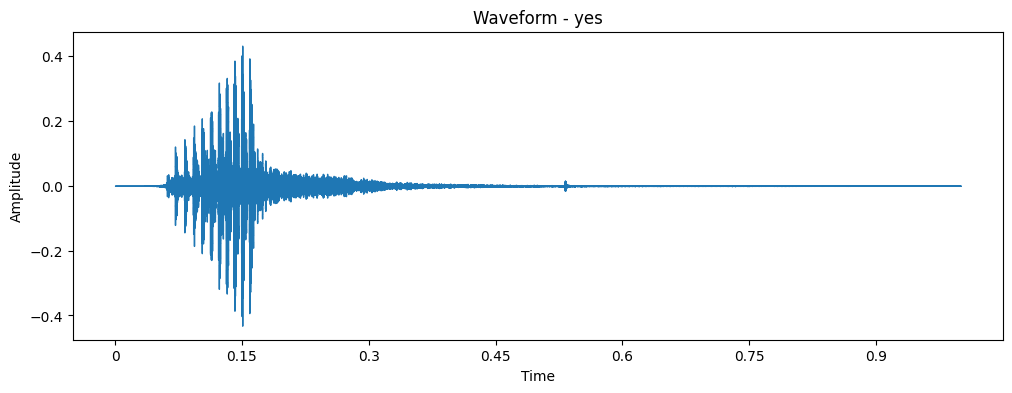

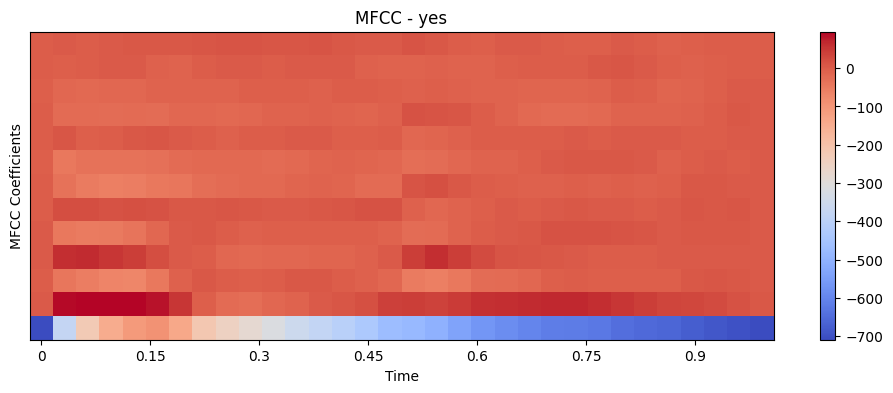

In [ ]:
#Visualize one audio file and its MFCC

sample_file = filepaths[0]
y, sr = librosa.load(sample_file, sr=16000)

print("Sample label:", labels[0])
print("Audio shape:", y.shape)
print("Sample rate:", sr)

# Waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform - {labels[0]}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

# MFCC
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc, x_axis="time", sr=sr)
plt.colorbar()
plt.title(f"MFCC - {labels[0]}")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.show()

In [ ]:
#Extract MFCC features for all files

def extract_mfcc(file_path, sr=16000, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc, axis=1)   # average across time

X_mfcc = np.array([extract_mfcc(fp) for fp in filepaths])

print("MFCC feature shape:", X_mfcc.shape)
print("First MFCC feature vector:", X_mfcc[0])

MFCC feature shape: (15625, 13)
First MFCC feature vector: [-461.6157      37.9832     -16.039387    11.350853    -5.771205
    5.461943   -14.060195   -13.658653    -0.6352011  -10.590761
   -7.8502674   -2.0735846    2.913783 ]


In [ ]:
#Improved MFCC feature extraction

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

def extract_mfcc(file_path, sr=16000, n_mfcc=20):
    y, sr = librosa.load(file_path, sr=sr)

    #Triming silence
    y, _ = librosa.effects.trim(y, top_db=20)

    # Pad short audio
    if len(y) < 2048:
        y = np.pad(y, (0, 2048 - len(y)))

    #Extracting MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=512,
        hop_length=160,
        win_length=400
    )

    #Adaptive delta width for short clips
    frame_count = mfcc.shape[1]
    delta_width = min(9, frame_count if frame_count % 2 == 1 else frame_count - 1)
    if delta_width < 3:
        delta_width = 3

    delta = librosa.feature.delta(mfcc, width=delta_width)
    delta2 = librosa.feature.delta(mfcc, order=2, width=delta_width)

    #Mean + std of MFCC, delta, delta-delta
    features = np.concatenate([
        np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
        np.mean(delta, axis=1), np.std(delta, axis=1),
        np.mean(delta2, axis=1), np.std(delta2, axis=1)
    ])

    return features

print("Extracting improved MFCC features...")
X_mfcc = np.array([extract_mfcc(fp) for fp in filepaths])

print("MFCC feature shape:", X_mfcc.shape)
print("First MFCC feature vector:", X_mfcc[0])

Extracting improved MFCC features...
MFCC feature shape: (15625, 120)
First MFCC feature vector: [-3.9416232e+02  4.2441708e+01 -2.3791496e+01  2.1015589e+01
 -1.5879803e+01  1.2097772e+01 -3.2753891e+01 -2.4748180e+01
  2.1439321e+00 -1.5252050e+01 -8.7601862e+00  1.4076936e+00
  7.1994801e+00  9.0687256e+00 -1.2181602e+01 -6.6077933e+00
  7.9622614e-01 -1.3029339e+01 -4.3362155e+00 -5.3663397e+00
  1.4774454e+02  6.1156639e+01  2.9116676e+01  3.2456711e+01
  2.2988628e+01  1.0613405e+01  1.6403667e+01  1.2061723e+01
  7.3408518e+00  8.8089542e+00  7.4355459e+00  6.3425550e+00
  7.4608860e+00  8.2399731e+00  8.8951740e+00  5.6660805e+00
  6.0622416e+00  1.0497543e+01  7.9796462e+00  6.1439142e+00
  1.1307513e+01 -2.3316631e+00  3.8174209e-01 -1.8475318e+00
  2.2478577e-01  5.5412039e-02 -3.0755079e-01  3.0143625e-01
 -2.2451697e-01 -5.8553511e-01  3.2277784e-01 -1.6765881e-01
  2.6898667e-01 -1.7279131e-02  1.1705999e-01  3.9482221e-02
 -5.7722613e-02 -2.2823645e-01 -3.5985869e-01  3.

In [ ]:
#Train/test split and improved MFCC classification

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)

#Spliting data
X_train, X_test, y_train, y_test = train_test_split(
    X_mfcc,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

#Training classifier with scaling
mfcc_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10, gamma="scale")
)

print("Training improved MFCC model...")
mfcc_clf.fit(X_train, y_train)

#Predicting
y_pred = mfcc_clf.predict(X_test)

#Evaluation
mfcc_accuracy = accuracy_score(y_test, y_pred)
print("Improved MFCC Accuracy:", mfcc_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Training improved MFCC model...
Improved MFCC Accuracy: 0.92096

Classification Report:

              precision    recall  f1-score   support

        down       0.88      0.88      0.88       783
          no       0.91      0.88      0.89       788
          up       0.93      0.96      0.95       745
         yes       0.97      0.96      0.97       809

    accuracy                           0.92      3125
   macro avg       0.92      0.92      0.92      3125
weighted avg       0.92      0.92      0.92      3125



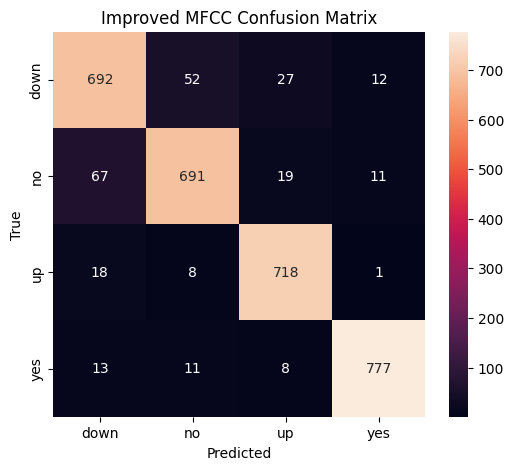

In [ ]:
#Confusion matrix for improved MFCC

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Improved MFCC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
#Improved FBANK feature extraction

def extract_fbank(file_path, sr=16000, n_mels=64):
    y, sr = librosa.load(file_path, sr=sr)

    #Triming silence
    y, _ = librosa.effects.trim(y, top_db=20)

    #Pad short audio
    if len(y) < 2048:
        y = np.pad(y, (0, 2048 - len(y)))

    #Extract log-Mel filter bank
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels,
        n_fft=512,
        hop_length=160,
        win_length=400
    )
    log_mel = librosa.power_to_db(mel)

    #Mean + std
    features = np.concatenate([
        np.mean(log_mel, axis=1),
        np.std(log_mel, axis=1)
    ])

    return features

print("Extracting improved FBANK features...")
X_fbank = np.array([extract_fbank(fp) for fp in filepaths])

print("FBANK feature shape:", X_fbank.shape)
print("First FBANK feature vector:", X_fbank[0])

Extracting improved FBANK features...


In [ ]:
#Train/test split and improved FBANK classification

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fbank,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

fbank_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10, gamma="scale")
)

print("Training improved FBANK model...")
fbank_clf.fit(X_train_f, y_train_f)

y_pred_f = fbank_clf.predict(X_test_f)

fbank_accuracy = accuracy_score(y_test_f, y_pred_f)
print("Improved FBANK Accuracy:", fbank_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test_f, y_pred_f, target_names=label_encoder.classes_))

In [ ]:
#Confusion matrix for improved FBANK + comparison plot

cm_f = confusion_matrix(y_test_f, y_pred_f)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_f,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Improved FBANK Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


#Compare MFCC and FBANK
methods = ["Improved MFCC", "Improved FBANK"]
accuracies = [mfcc_accuracy, fbank_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(methods, accuracies)
plt.title("Improved MFCC vs Improved FBANK Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

print("Improved MFCC Accuracy:", mfcc_accuracy)
print("Improved FBANK Accuracy:", fbank_accuracy)

In [19]:

#IMPROVED MFCC + TRAINING
#CORRECTED FOR SHORT AUDIO

import numpy as np
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


def extract_mfcc(file_path, sr=16000, n_mfcc=20):
    y, sr = librosa.load(file_path, sr=sr)

    #Trim silence
    y, _ = librosa.effects.trim(y, top_db=20)

    #If audio becomes too short, pad it
    if len(y) < 2048:
        y = np.pad(y, (0, 2048 - len(y)))

    #Use smaller FFT/window settings for short clips
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=512,
        hop_length=160,
        win_length=400
    )

    #Make sure delta width is valid for short sequences
    frame_count = mfcc.shape[1]
    delta_width = min(9, frame_count if frame_count % 2 == 1 else frame_count - 1)

    #Fallback if still too small
    if delta_width < 3:
        delta_width = 3

    delta = librosa.feature.delta(mfcc, width=delta_width)
    delta2 = librosa.feature.delta(mfcc, order=2, width=delta_width)

    features = np.concatenate([
        np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
        np.mean(delta, axis=1), np.std(delta, axis=1),
        np.mean(delta2, axis=1), np.std(delta2, axis=1)
    ])

    return features


print("Extracting improved MFCC features...")
X_mfcc = np.array([extract_mfcc(fp) for fp in filepaths])
print("Feature shape:", X_mfcc.shape)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X_mfcc,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10, gamma="scale")
)

print("Training model...")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("\nImproved MFCC Accuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Extracting improved MFCC features...
Feature shape: (15625, 120)
Training model...

Improved MFCC Accuracy: 0.92096

Classification Report:

              precision    recall  f1-score   support

        down       0.88      0.88      0.88       783
          no       0.91      0.88      0.89       788
          up       0.93      0.96      0.95       745
         yes       0.97      0.96      0.97       809

    accuracy                           0.92      3125
   macro avg       0.92      0.92      0.92      3125
weighted avg       0.92      0.92      0.92      3125



In [20]:
#Noise function

def add_noise(y, snr_db):
    signal_power = np.mean(y ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), size=y.shape)
    return y + noise

In [21]:
#Noisy MFCC extraction

def extract_mfcc_noisy(file_path, snr_db, sr=16000, n_mfcc=20):
    y, sr = librosa.load(file_path, sr=sr)

    y = add_noise(y, snr_db)

    y, _ = librosa.effects.trim(y, top_db=20)

    if len(y) < 2048:
        y = np.pad(y, (0, 2048 - len(y)))

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=512,
        hop_length=160,
        win_length=400
    )

    frame_count = mfcc.shape[1]
    delta_width = min(9, frame_count if frame_count % 2 == 1 else frame_count - 1)
    if delta_width < 3:
        delta_width = 3

    delta = librosa.feature.delta(mfcc, width=delta_width)
    delta2 = librosa.feature.delta(mfcc, order=2, width=delta_width)

    features = np.concatenate([
        np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
        np.mean(delta, axis=1), np.std(delta, axis=1),
        np.mean(delta2, axis=1), np.std(delta2, axis=1)
    ])

    return features

In [22]:
#Evaluate MFCC under noise

snr_values = [20, 10, 0]
mfcc_noise_scores = []

for snr in snr_values:
    print(f"\nTesting at SNR = {snr} dB")

    X_noisy = np.array([extract_mfcc_noisy(fp, snr) for fp in filepaths])

    X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
        X_noisy,
        y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )

    clf = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=10, gamma="scale")
    )

    clf.fit(X_train_n, y_train_n)
    preds = clf.predict(X_test_n)

    acc = accuracy_score(y_test_n, preds)
    print(f"Accuracy @ {snr} dB:", acc)

    mfcc_noise_scores.append(acc)


Testing at SNR = 20 dB
Accuracy @ 20 dB: 0.92288

Testing at SNR = 10 dB
Accuracy @ 10 dB: 0.90688

Testing at SNR = 0 dB
Accuracy @ 0 dB: 0.85664


Using device: cuda
GPU Name: Tesla T4
yes: 4044 files
no: 3941 files
up: 3723 files
down: 3917 files
Total files loaded: 15625
Subset for yes: 200 files
Subset for no: 200 files
Subset for up: 200 files
Subset for down: 200 files
Subset size: 800
Classes: ['down' 'no' 'up' 'yes']


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting wav2vec features...
Processed 0/800
Processed 50/800
Processed 100/800
Processed 150/800
Processed 200/800
Processed 250/800
Processed 300/800
Processed 350/800
Processed 400/800
Processed 450/800
Processed 500/800
Processed 550/800
Processed 600/800
Processed 650/800
Processed 700/800
Processed 750/800
wav2vec feature shape: (800, 768)
Training wav2vec classifier...

wav2vec Accuracy: 0.94375

Classification Report:

              precision    recall  f1-score   support

        down       0.97      0.90      0.94        40
          no       0.92      0.90      0.91        40
          up       0.89      1.00      0.94        40
         yes       1.00      0.97      0.99        40

    accuracy                           0.94       160
   macro avg       0.95      0.94      0.94       160
weighted avg       0.95      0.94      0.94       160



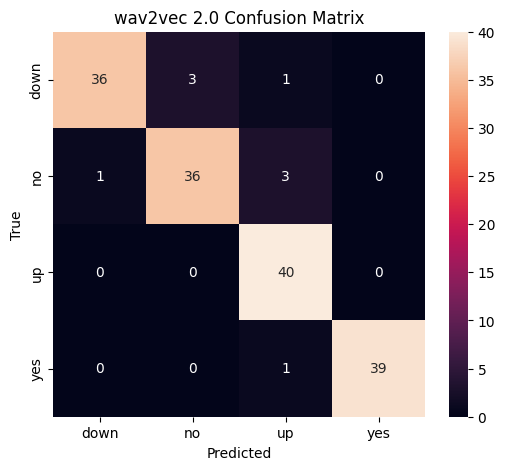

In [24]:
#wav2vec 2.0 feature extraction + classification
#Self-contained version for Colab / Kaggle runtime resets

import os
import glob
import numpy as np
import librosa
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import Wav2Vec2Processor, Wav2Vec2Model

#1. Basic setup
DATASET_PATH = "/kaggle/input/speech-commands"
TARGET_CLASSES = ["yes", "no", "up", "down"]
MAX_PER_CLASS = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))


#2. Reload dataset from disk
def load_dataset(data_dir, target_classes):
    filepaths = []
    labels = []

    for label in target_classes:
        class_dir = os.path.join(data_dir, label)

        if not os.path.isdir(class_dir):
            print(f"Missing folder: {class_dir}")
            continue

        wav_files = sorted(glob.glob(os.path.join(class_dir, "*.wav")))
        print(f"{label}: {len(wav_files)} files")

        for wav in wav_files:
            filepaths.append(wav)
            labels.append(label)

    return filepaths, labels


filepaths, labels = load_dataset(DATASET_PATH, TARGET_CLASSES)
print("Total files loaded:", len(filepaths))

if len(filepaths) == 0:
    raise ValueError("No files were loaded. Check DATASET_PATH and folder names.")


#3. Build subset safely
subset_filepaths = []
subset_labels = []

for label in TARGET_CLASSES:
    class_files = [fp for fp, lb in zip(filepaths, labels) if lb == label]
    class_subset = class_files[:MAX_PER_CLASS]

    subset_filepaths.extend(class_subset)
    subset_labels.extend([label] * len(class_subset))

    print(f"Subset for {label}: {len(class_subset)} files")

print("Subset size:", len(subset_filepaths))

if len(subset_filepaths) == 0:
    raise ValueError("Subset is empty. Check dataset loading and class names.")


#4. Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(TARGET_CLASSES)
subset_y_encoded = label_encoder.transform(subset_labels)

print("Classes:", label_encoder.classes_)


# 5.Load wav2vec model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec_model.to(device)
wav2vec_model.eval()


#6. Feature extraction
def extract_wav2vec_feature(file_path, target_sr=16000):
    y, sr = librosa.load(file_path, sr=target_sr)

    #optional trim
    y, _ = librosa.effects.trim(y, top_db=20)

    #ensure not too short
    if len(y) < 400:
        y = np.pad(y, (0, 400 - len(y)))

    inputs = processor(
        y,
        sampling_rate=target_sr,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = wav2vec_model(input_values)

    hidden_states = outputs.last_hidden_state.squeeze(0)   # [time, hidden]
    feature = hidden_states.mean(dim=0).cpu().numpy()     # [hidden]
    return feature

#7. Extract features for subset
print("Extracting wav2vec features...")
X_wav2vec = []

for i, fp in enumerate(subset_filepaths):
    if i % 50 == 0:
        print(f"Processed {i}/{len(subset_filepaths)}")

    try:
        feat = extract_wav2vec_feature(fp)
        X_wav2vec.append(feat)
    except Exception as e:
        print(f"Skipping {fp} بسبب error: {e}")

X_wav2vec = np.array(X_wav2vec)
print("wav2vec feature shape:", X_wav2vec.shape)

if len(X_wav2vec) == 0:
    raise ValueError("No wav2vec features were extracted.")


#8. Align labels if any files were skipped
valid_count = len(X_wav2vec)
subset_y_encoded = subset_y_encoded[:valid_count]


#9.Train/test split
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wav2vec,
    subset_y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=subset_y_encoded
)

#10.Train classifier
wav2vec_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10, gamma="scale")
)

print("Training wav2vec classifier...")
wav2vec_clf.fit(X_train_w, y_train_w)


#11. Evaluate
y_pred_w = wav2vec_clf.predict(X_test_w)

wav2vec_accuracy = accuracy_score(y_test_w, y_pred_w)
print("\nwav2vec Accuracy:", wav2vec_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test_w, y_pred_w, target_names=label_encoder.classes_))


# 12. Confusion matrix
cm_w = confusion_matrix(y_test_w, y_pred_w)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_w,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("wav2vec 2.0 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()